![bingo-logo](../content/00_images/bingo_logo.png)

# Budget Analysis and BINGO Specifications

In [1]:
import numpy as np
import pandas as pd


def reais(val):
    """
    Convert a value to Brazilian Real format.

    Parameters:
    val (float): The value to be converted.

    Returns:
    str: The value formatted as Brazilian Real.
    """
    return f"R$ {val:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

In [2]:
RECURSOS = {
    "FAPESQ_FITE": 2357217.95,
    "FINEP_FITE": 891059.78,
    "FAPESQ_FINEP": 4000000,
    "FINEP_NOVO": 10000000,
}
df_RECURSOS = pd.DataFrame(RECURSOS.items(), columns=["Funding Source", "Amount"])
df_RECURSOS["Valor"] = df_RECURSOS["Amount"].apply(
    reais
)  # Format the amount in Brazilian currency format
print(df_RECURSOS)
print(f"\ntotal: {reais(df_RECURSOS.Amount.sum())}")

  Funding Source       Amount             Valor
0    FAPESQ_FITE   2357217.95   R$ 2.357.217,95
1     FINEP_FITE    891059.78     R$ 891.059,78
2   FAPESQ_FINEP   4000000.00   R$ 4.000.000,00
3     FINEP_NOVO  10000000.00  R$ 10.000.000,00

total: R$ 17.248.277,73


## Configurações

- 15 cornetas
- 15 skarabs
- Cabeamento RF curto dos receptores até as skarabs
- Cabeamento ótico das skarabs para casa de comando

## Requisitos Mínimos

### Torre

| Item                                              |            Qtd. | Faixa unitária |          Subtotal |
| ------------------------------------------------- | --------------: | -------------: | ----------------: |
| Cabos RF externos montados e testados             | 30 + 3 reservas |    US$ 100–200 |   US$ 3,3–6,6 mil |
| Gabinetes externos climatizados                   |               4 |    US$ 4–6 mil |     US$ 16–24 mil |
| Alimentação, quadro, DPS e distribuição           |          1 lote |              — |      US$ 8–15 mil |
| UPS online 6 kVA com bypass                       |               1 |    US$ 4–8 mil |       US$ 4–8 mil |
| Distribuição de clock e 1PPS                      |       1 sistema |              — |       US$ 5–8 mil |
| QSFP+ 40G LR4/IR4                                 | 30 + 4 reservas |    US$ 300–600 | US$ 10,2–20,4 mil |
| Tronco OS2 externo de 48 fibras instalado         |       200–250 m |              — |      US$ 8–20 mil |
| DIOs, caixas, pigtails, emendas e patch cords     |          1 lote |              — |       US$ 3–5 mil |
| Rede de gerenciamento 1 GbE                       |          1 lote |              — |     US$ 1,5–3 mil |
| Monitoramento ambiental e elétrico                |     4 gabinetes |              — |       US$ 2–4 mil |
| SPDA, equipotencialização e proteção complementar |          1 lote |              — |       US$ 3–6 mil |
| Comissionamento RF/óptico/sincronismo             |       1 serviço |              — |      US$ 8–12 mil |

### Casa de Comando

| Item                                        |   Qtd. |      Subtotal |
| ------------------------------------------- | -----: | ------------: |
| Switch 40/100GbE de 24–32 portas            |      1 | US$ 10–20 mil |
| NIC de servidor, preferencialmente 2×100GbE |      1 | US$ 1,5–4 mil |
| Ópticos/DACs do uplink                      |    2–4 |   US$ 1–3 mil |
| Rack, PDUs e organização óptica             | 1 lote |   US$ 2–5 mil |


In [3]:
dolar_cheio = 8
RF = {"min": 72000, "max": 132000}
df_RF = pd.DataFrame(RF.items(), columns=["Range", "U$"])
df_RF["R$"] = df_RF["U$"].apply(
    lambda x: reais(x * dolar_cheio)
)  # Convert to Brazilian Real
print("\nCusto Cabeamento RF:")
print(df_RF)


Custo Cabeamento RF:
  Range      U$               R$
0   min   72000    R$ 576.000,00
1   max  132000  R$ 1.056.000,00


## Itens necessários

- Estação Metereológica R$20.000,00
- Master Clock R$40.000,00
- Sensores de geometria R$50.000,00
- As built + posicionamento R$100.000,00
- baterias backup R$40.000,00
- Placas Solares R$20.0000,00
- Ar condicionado R$15.000,00
- Projetos R$200.000,00
- Receptores R$4.000.000,00
- Operacional R$500.000,00



In [4]:
necessarios = (
    20000 + 40000 + 50000 + 100000 + 40000 + 20000 + 15000 + 200000 + 4000000 + 500000
)
df_Custos = df_RF
df_Custos["RF(R$)"] = (
    df_Custos["U$"].mean() * dolar_cheio
)  # Calculate the average cost in Brazilian Real
df_Custos["Necessários(R$)"] = reais(
    necessarios
)  # Format the necessary amount in Brazilian currency format
df_Custos["Total"] = df_Custos["RF(R$)"] + necessarios  # Calculate the total cost
df_Custos = df_Custos[["RF(R$)", "Necessários(R$)", "Total"]]  # Reorder columns
print("\nCusto Cabeamento RF com Necessários:")
print(df_Custos.head(1))


Custo Cabeamento RF com Necessários:
     RF(R$)  Necessários(R$)      Total
0  816000.0  R$ 4.985.000,00  5801000.0


## Elementos iniciais para a discussão

- Quais são os requisitos de ciência que queremos atingir?
- Em quanto tempo pretendemos atingir esta meta?
- Existem passos intermediários?
- Quanto tempo esta previsto para comissionamento?
- Devemos considerar o risco de obsolescência tecnológica?

## Casos de Ciência

### Cosmologia

#### Instrument
- **Horns** --  $N_\mathrm{Horns} = 15$
- **FWHM** --  $\theta = 40 \;\mathrm{arcmin}$
- **Bandwidth** -- $375 \;\mathrm{MHz}$
- **Central Frequency** -- $1120 \;\mathrm{MHz}$
- * λ ≈ 0.27 m
- **Effective Area** -- 
$$
\eta = 0.7, \; \Omega = \frac{\pi}{4 \log 2} \theta^2 \approx 1.133\,\theta^2 \\
A_{\text{eff}} = \eta \left(\frac{c}{\bar\nu}\right)^2 \frac{1}{\Omega} \approx 327 \, \text{m}^2
$$
- **Total Effective Area** -- $\mathcal{A}_{\text{eff}} = N_\mathrm{Horns} A_{\text{eff}} \approx 4.9 \times 10^3 \, \text{m}^2$
- **System Temperature** -- $T_{Sys} = 40 \,\text{K}$
- **Integration Time** -- $\tau = 1\;\mathrm{ms} - 1\;\mathrm{s}$
- **FFT** -- $N_\mathrm{FFT} = 1024 - 4096$
- **Channels** -- $4$

#### SEFD 

$$
SEFD = \frac{2k T_{\text{sys}}}{A_{\text{eff}}} \approx 338 \;\mathrm{Jy}
$$

#### Sensitivity

$$
\Delta S = \frac{SEFD}{\sqrt{B \tau}}
$$

#### Channel Sensitivity

$$
\Delta S_{\text{canal}} = \frac{SEFD}{\sqrt{\Delta\nu \tau}}
$$

### Grandezas calculadas — $A_\mathrm{eff}$, SEFD e sensibilidade

Cálculo com os valores indicados acima: $N_\mathrm{Horns}=15$, $\eta=0.7$, $\theta=40'$, $B=375$ MHz, $\bar\nu=1120$ MHz, $T_\mathrm{sys}=40$ K, $\tau=1$ ms – 1 s, $N_\mathrm{FFT}=1024$–4096.

- **Área efetiva**: uma corneta ($A_\mathrm{eff}$) e a soma das 15 ($\mathcal{A}_\mathrm{eff} = N_\mathrm{Horns} A_\mathrm{eff}$), admitindo que as 15 cornetas coletam o mesmo céu.
- **SEFD**: $\mathrm{SEFD} = 2kT_\mathrm{sys}/A_\mathrm{eff}$, em Jy, para uma corneta e para as 15.
- **Sensibilidade**: $\Delta S = \mathrm{SEFD}/\sqrt{B\tau}$ (banda total $B$).
- **Sensibilidade por canal**: $\Delta S_\mathrm{canal} = \mathrm{SEFD}/\sqrt{\Delta\nu\,\tau}$, com $\Delta\nu = B/N_\mathrm{FFT}$.

Os **intervalos** vêm das faixas indicadas de $\tau$ e $N_\mathrm{FFT}$ ($\eta$, $\theta$ e $T_\mathrm{sys}$ ficam fixos nos valores nominais).



In [5]:
# ---------------------------------------------------------------------------
# Grandezas derivadas: área efetiva e SEFD
# ---------------------------------------------------------------------------
c = 299_792_458.0  # velocidade da luz [m/s]
k_B = 1.380_649e-23  # constante de Boltzmann [J/K]
JY = 1e-26  # 1 Jy = 1e-26 W m^-2 Hz^-1

N_HORNS = 15  # cornetas
THETA_ARCMIN = 40.0  # FWHM [arcmin]
ETA = 0.7  # eficiência de abertura
B_HZ = 375e6  # banda total [Hz]
NU_BAR_HZ = 1120e6  # frequência central [Hz]
T_SYS_K = 40.0  # temperatura de sistema [K]
TAU_S = np.array([1e-3, 1e-2, 1e-1, 1.0])  # integração: 1 ms - 1 s
N_FFT = np.array([1024, 2048, 4096])  # 1024 - 4096
N_CHANNELS = 4

# --- feixe gaussiano e área efetiva ------------------------------------------
theta_rad = np.deg2rad(THETA_ARCMIN / 60)
omega_beam = np.pi / (4 * np.log(2)) * theta_rad**2  # sólido ≈ 1,133 θ²
lam = c / NU_BAR_HZ

a_eff_1 = ETA * lam**2 / omega_beam  # área efetiva de UMA corneta
a_eff_tot = N_HORNS * a_eff_1  # área efetiva do conjunto das 15


# --- SEFD --------------------------------------------------------------------
def sefd_jy(a_eff, t_sys=T_SYS_K):
    """SEFD [Jy] para uma área efetiva coletora em m²."""
    return 2 * k_B * t_sys / (a_eff * JY)


sefd_1 = sefd_jy(a_eff_1)  # 1 corneta
sefd_tot = sefd_jy(a_eff_tot)  # 15 cornetas, área total (soma coerente)
sefd_inc = sefd_1 / np.sqrt(N_HORNS)  # 15 cornetas, potência somada (√N)

print(f"λ̄                        = {lam:.4f} m")
print(
    f"Ω_feixe                  = {omega_beam:.4e} sr  ({omega_beam / theta_rad**2:.3f} θ²)"
)
print(f"A_eff (1 corneta)        = {a_eff_1:,.1f} m²")
print(f"A_eff (15 cornetas)      = {a_eff_tot:,.1f} m²")
print(f"SEFD (1 corneta)         = {sefd_1:,.1f} Jy")
print(f"SEFD (15, coerente)      = {sefd_tot:,.1f} Jy")
print(f"SEFD (15, √N potência)   = {sefd_inc:,.1f} Jy")

λ̄                        = 0.2677 m
Ω_feixe                  = 1.5340e-04 sr  (1.133 θ²)
A_eff (1 corneta)        = 326.9 m²
A_eff (15 cornetas)      = 4,904.1 m²
SEFD (1 corneta)         = 337.8 Jy
SEFD (15, coerente)      = 22.5 Jy
SEFD (15, √N potência)   = 87.2 Jy


In [6]:
# --- sensibilidade: ΔS = SEFD/√(B τ)  e  ΔS_canal = SEFD/√(Δν τ) -----------
casos = {
    "1 corneta": sefd_1,
    "15 cornetas (coerente / A_eff total)": sefd_tot,
    "15 cornetas (potência somada / √N)": sefd_inc,
}

registros = []
for caso, sefd_caso in casos.items():
    for tau in TAU_S:
        for n_fft in N_FFT:
            dnu = B_HZ / n_fft  # banda por canal do FFT
            registros.append(
                {
                    "Caso": caso,
                    "τ [s]": tau,
                    "N_FFT": n_fft,
                    "Δν canal [MHz]": dnu / 1e6,
                    "ΔS banda [Jy]": sefd_caso / np.sqrt(B_HZ * tau),
                    "ΔS canal [Jy]": sefd_caso / np.sqrt(dnu * tau),
                }
            )

df_sens = pd.DataFrame(registros)

for caso, sefd_caso in casos.items():
    print(f"\n=== {caso} — SEFD = {sefd_caso:,.1f} Jy ===")
    tabela = df_sens.loc[df_sens.Caso == caso].drop(columns="Caso")
    print(tabela.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

print("\n=== Intervalos de sensibilidade ===")
for caso in casos:
    sub = df_sens.loc[df_sens.Caso == caso]
    banda, canal = sub["ΔS banda [Jy]"], sub["ΔS canal [Jy]"]
    print(
        f"{caso:38s} banda: {banda.min():.3g} – {banda.max():.3g} Jy"
        f" | canal: {canal.min():.3g} – {canal.max():.3g} Jy"
    )

# --- se os 4 "Channels" forem sub-bandas de B/4 ------------------------------
dnu_sub = B_HZ / N_CHANNELS

# --- robustez a η (0,6 - 0,8) -----------------------------------------------
print("\nRobustez a η (T_sys = 40 K):")
for eta in (0.6, 0.7, 0.8):
    a_1 = eta * lam**2 / omega_beam
    print(
        f"η = {eta:.1f} → A_eff = {a_1:,.0f} m²"
        f" | SEFD = {sefd_jy(a_1):,.0f} Jy"
        f" | SEFD(15, coerente) = {sefd_jy(N_HORNS * a_1):,.1f} Jy"
    )


=== 1 corneta — SEFD = 337.8 Jy ===
 τ [s]  N_FFT  Δν canal [MHz]  ΔS banda [Jy]  ΔS canal [Jy]
 0.001   1024          0.3662         0.5517          17.65
 0.001   2048          0.1831         0.5517          24.97
 0.001   4096         0.09155         0.5517          35.31
  0.01   1024          0.3662         0.1745          5.583
  0.01   2048          0.1831         0.1745          7.895
  0.01   4096         0.09155         0.1745          11.17
   0.1   1024          0.3662        0.05517          1.765
   0.1   2048          0.1831        0.05517          2.497
   0.1   4096         0.09155        0.05517          3.531
     1   1024          0.3662        0.01745         0.5583
     1   2048          0.1831        0.01745         0.7895
     1   4096         0.09155        0.01745          1.117

=== 15 cornetas (coerente / A_eff total) — SEFD = 22.5 Jy ===
 τ [s]  N_FFT  Δν canal [MHz]  ΔS banda [Jy]  ΔS canal [Jy]
 0.001   1024          0.3662        0.03678          1.177


### Data rate da SKARAB

Modelo adotado para a saída de cada SKARAB, com os valores indicados:

- **Entrada**: ADC de **14 bits** amostrando a banda de $B=375$ MHz em I/Q, com $\Delta\nu = B/N_\mathrm{FFT}$.
- **Saída**: $N_\mathrm{produtos} = 8$ produtos reais de **16 bits** por canal e por integração.

$$\text{taxa} = \frac{N_\mathrm{FFT} \times N_\mathrm{produtos} \times 16\ \mathrm{bits}}{\tau}$$

Sem integração a taxa de produtos **não depende de $N_\mathrm{FFT}$** (o canal é atualizado a cada $1/\Delta\nu$, logo são $B$ atualizações/s):

$$R_\text{cru} = B \times 8 \times 16 = 48\ \mathrm{Gbit/s\ por\ SKARAB}$$

ou seja, é a integração ($\tau$) que reduz a taxa, por um fator $B\tau/N_\mathrm{FFT}$.

In [7]:
# ---------------------------------------------------------------------------
# Data rate da SKARAB: entrada 14 bits, saída 8 produtos reais de 16 bits
# ---------------------------------------------------------------------------
BITS_ADC = 14  # quantização da entrada (ADC)
BITS_PRODUTO = 16  # bits por produto real na saída
N_PRODUTOS = 8  # produtos reais por canal e por integração
F_S_HZ = B_HZ  # amostragem I/Q de 375 MHz → Δν = B/N_FFT


def taxa_str(bits_por_s):
    """Formata uma taxa de bits/s com a unidade mais adequada."""
    for escala, unidade in ((1e9, "Gbit/s"), (1e6, "Mbit/s"), (1e3, "kbit/s")):
        if bits_por_s >= escala:
            return f"{bits_por_s / escala:,.2f} {unidade}"
    return f"{bits_por_s:,.0f} bit/s"


def bytes_str(bytes_):
    """Formata um volume de bytes com a unidade mais adequada."""
    for escala, unidade in ((1e9, "GB"), (1e6, "MB"), (1e3, "kB")):
        if bytes_ >= escala:
            return f"{bytes_ / escala:,.2f} {unidade}"
    return f"{bytes_:,.0f} B"


# Taxa de entrada (ADC): independe de N_FFT e de τ
taxa_in = F_S_HZ * BITS_ADC
print(
    f"Entrada (ADC {BITS_ADC} bits @ {F_S_HZ / 1e6:.0f} Msps): "
    f"{taxa_str(taxa_in)} = {bytes_str(taxa_in / 8)}/s por entrada"
)

# Taxa crua de produtos (sem integração): cada canal é atualizado a cada 1/Δν,
# logo N_FFT × Δν = B atualizações/s → independente de N_FFT
taxa_crua = B_HZ * N_PRODUTOS * BITS_PRODUTO
print(
    f"Saída crua, sem integração (8 produtos × 16 bits, B = {B_HZ / 1e6:.0f} MHz): "
    f"{taxa_str(taxa_crua)} por SKARAB"
)

registros = []
for tau in (1e-3, 1.0):
    for n_fft in N_FFT:
        bits_integr = n_fft * N_PRODUTOS * BITS_PRODUTO
        taxa = bits_integr / tau
        registros.append(
            {
                "τ [s]": tau,
                "N_FFT": n_fft,
                "Δν [MHz]": B_HZ / n_fft / 1e6,
                "Volume/integração": bytes_str(bits_integr / 8),
                "Taxa/SKARAB": taxa_str(taxa),
                "Taxa 15 SKARABs": taxa_str(N_HORNS * taxa),
                "Frames/integração": taxa_crua / taxa,
            }
        )

df_rate = pd.DataFrame(registros)
print("\nData rate da SKARAB (unidades decimais: 1 Mbit = 1e6 bits, 1 MB = 1e6 bytes)")
print(df_rate.to_string(index=False, float_format=lambda v: f"{v:,.4g}"))

# --- resumo em matriz: linhas = τ, colunas = N_FFT ---------------------------
for coluna in ("Taxa/SKARAB", "Taxa 15 SKARABs"):
    matriz = df_rate.pivot(index="τ [s]", columns="N_FFT", values=coluna)
    print(f"\n{coluna} (colunas = N_FFT)")
    print(matriz.to_string())

taxa_agregada = df_rate.loc[df_rate["τ [s]"] == 1e-3, "Taxa 15 SKARABs"].iloc[-1]
print(
    f"\nPior caso agregado (τ = 1 ms, N_FFT = {N_FFT[-1]}): {taxa_agregada}"
    " → link de 10GbE no limite (≈80% de eficiência útil);"
    " QSFP+ 40G oferece folga."
)

Entrada (ADC 14 bits @ 375 Msps): 5.25 Gbit/s = 656.25 MB/s por entrada
Saída crua, sem integração (8 produtos × 16 bits, B = 375 MHz): 48.00 Gbit/s por SKARAB

Data rate da SKARAB (unidades decimais: 1 Mbit = 1e6 bits, 1 MB = 1e6 bytes)
 τ [s]  N_FFT  Δν [MHz] Volume/integração   Taxa/SKARAB Taxa 15 SKARABs  Frames/integração
 0.001   1024    0.3662          16.38 kB 131.07 Mbit/s     1.97 Gbit/s              366.2
 0.001   2048    0.1831          32.77 kB 262.14 Mbit/s     3.93 Gbit/s              183.1
 0.001   4096   0.09155          65.54 kB 524.29 Mbit/s     7.86 Gbit/s              91.55
     1   1024    0.3662          16.38 kB 131.07 kbit/s     1.97 Mbit/s          3.662e+05
     1   2048    0.1831          32.77 kB 262.14 kbit/s     3.93 Mbit/s          1.831e+05
     1   4096   0.09155          65.54 kB 524.29 kbit/s     7.86 Mbit/s          9.155e+04

Taxa/SKARAB (colunas = N_FFT)
N_FFT           1024           2048           4096
τ [s]                                      

### Processamento SKARAB

- FIR high Pass para filtrar região GSM?
- PFB 12 taps
- FFT
- RFI?
- Packetização
- SPEAD

### Data Center

- Demanda de processamento:
    -  ordenamento, RFI, Calibração, gridding: $\approx 200 \mathrm{Flops/sp} \approx 50 \mathrm{GFlops}$
    - Heimdall: \approx 1 \mathrm{TFlops}$


#### Nós de computação e Storage — preços médios em R$

Tabelas geradas a partir das faixas de preço unitário em US$ (mantidas apenas como dado de entrada no código), mostrando **somente** o preço médio unitário e o subtotal médio em reais, com a cotação definida no notebook (`dolar_cheio` = **R$ 8,00/US$**).

- Unit. médio (R$) = $(US\$_\text{mín} + US\$_\text{máx})/2 \times 8$
- Subtotal = preço unitário $\times$ Qtd/nó $\times$ Nós

In [8]:
# ---------------------------------------------------------------------------
# Nós de computação e storage — preços médios em R$ (cotação US$ 1 = R$ 8,00)
# ---------------------------------------------------------------------------
from IPython.display import Markdown, display

COTACAO = dolar_cheio  # R$ por US$ — cotação definida em "Custo Cabeamento RF"

NOS_COMPUTACAO = [
    {
        "Item": "Servidor 2U dual-socket EPYC",
        "Especificação": (
            "Chassi + PSU redundante + 2x AMD EPYC 9004/9005 (24-32 cores "
            "totais), suporte a 2x GPU dual-slot"
        ),
        "Qtd/nó": 1,
        "Nós": 3,
        "US$ mín": 8000,
        "US$ máx": 15000,
    },
    {
        "Item": "RAM DDR5 ECC RDIMM",
        "Especificação": (
            "512 GB por nó — dimensionado para reter buffer de voltagem bruta "
            "em torno de candidatos a FRB"
        ),
        "Qtd/nó": 1,
        "Nós": 3,
        "US$ mín": 3500,
        "US$ máx": 5000,
    },
    {
        "Item": "GPU leve — NVIDIA L4 24GB",
        "Especificação": (
            "Ingest/reorder + RFI + calibração + gridding + sourcefind "
            "(~100 GFLOPs necessários, folga ampla)"
        ),
        "Qtd/nó": 1,
        "Nós": 3,
        "US$ mín": 2500,
        "US$ máx": 3000,
    },
    {
        "Item": "GPU pesada — NVIDIA RTX 6000 Ada 48GB",
        "Especificação": (
            "Dedispersão + busca de FRB (Heimdall). ECC, 960GB/s, blower — "
            "substitui A100 com ~40% de economia"
        ),
        "Qtd/nó": 1,
        "Nós": 3,
        "US$ mín": 6000,
        "US$ máx": 8000,
    },
    {
        "Item": "NIC 40GbE QSFP+ dual-port",
        "Especificação": "Uplink para o switch core",
        "Qtd/nó": 1,
        "Nós": 3,
        "US$ mín": 400,
        "US$ máx": 800,
    },
    {
        "Item": "NVMe local (buffer) — kit",
        "Especificação": (
            "4x NVMe enterprise mixed-use 2-4TB, RAID10 — absorve picos e "
            "permite replay + dump de voltagem"
        ),
        "Qtd/nó": 1,
        "Nós": 3,
        "US$ mín": 1600,
        "US$ máx": 2800,
    },
    {
        "Item": "Boot drives (SO)",
        "Especificação": "2x SSD SATA 480GB RAID1",
        "Qtd/nó": 1,
        "Nós": 3,
        "US$ mín": 150,
        "US$ máx": 300,
    },
]

STORAGE = [
    {
        "Item": "Chassi 4U hot-swap, 24-36 baias",
        "Especificação": "P/ discos + fonte redundante",
        "Qtd/nó": 1,
        "Nós": 1,
        "US$ mín": 3000,
        "US$ máx": 5000,
    },
    {
        "Item": 'Servidor "head" de storage',
        "Especificação": (
            "1x CPU (Xeon/EPYC single-socket) + 256GB RAM ECC (ZFS ARC cache)"
        ),
        "Qtd/nó": 1,
        "Nós": 1,
        "US$ mín": 3000,
        "US$ máx": 5000,
    },
    {
        "Item": "HBA modo IT (passthrough)",
        "Especificação": (
            "Ex.: LSI/Broadcom 9400-16i — necessário p/ ZFS acessar discos diretamente"
        ),
        "Qtd/nó": 2,
        "Nós": 1,
        "US$ mín": 400,
        "US$ máx": 700,
    },
    {
        "Item": "HD enterprise nearline 16TB (SAS/SATA)",
        "Especificação": "12 discos, RAIDZ2 (2 discos de paridade) — ≈160TB úteis",
        "Qtd/nó": 12,
        "Nós": 1,
        "US$ mín": 250,
        "US$ máx": 350,
    },
    {
        "Item": "NIC 25/100GbE dual-port",
        "Especificação": "Uplink ao switch core",
        "Qtd/nó": 1,
        "Nós": 1,
        "US$ mín": 500,
        "US$ máx": 900,
    },
    {
        "Item": "Software (TrueNAS SCALE ou Ceph)",
        "Especificação": "Open-source, sem custo de licença",
        "Qtd/nó": 1,
        "Nós": 1,
        "US$ mín": 0,
        "US$ máx": 0,
    },
]


def tabela_precos(itens):
    """DataFrame com preço médio unitário e subtotal médio, em R$."""
    registros = []
    for item in itens:
        qtd_no, nos = item["Qtd/nó"], item["Nós"]
        unit_medio = (item["US$ mín"] + item["US$ máx"]) / 2 * COTACAO
        registros.append(
            {
                "Item": item["Item"],
                "Especificação": item["Especificação"],
                "Qtd/nó": qtd_no,
                "Nós": nos,
                "Unit. médio (R$)": unit_medio,
                "Subtotal médio (R$)": unit_medio * qtd_no * nos,
            }
        )
    return pd.DataFrame(registros)


def markdown_tabela(df, formatos):
    """Monta uma tabela Markdown a partir de um DataFrame (sem tabulate)."""
    separador = ["---:" if coluna in formatos else "---" for coluna in df.columns]
    linhas = [
        "| " + " | ".join(df.columns) + " |",
        "| " + " | ".join(separador) + " |",
    ]
    for _, linha in df.iterrows():
        celulas = [
            formatos[coluna](linha[coluna])
            if coluna in formatos
            else str(linha[coluna])
            for coluna in df.columns
        ]
        linhas.append("| " + " | ".join(celulas) + " |")
    return "\n".join(linhas)


COLUNAS_RS = ("Unit. médio (R$)", "Subtotal médio (R$)")
FORMATOS = {coluna: reais for coluna in COLUNAS_RS}

df_nos = tabela_precos(NOS_COMPUTACAO)
df_storage = tabela_precos(STORAGE)

df_totais = pd.DataFrame(
    [
        {
            "Bloco": "Nós de computação (3x)",
            "Subtotal médio (R$)": df_nos["Subtotal médio (R$)"].sum(),
        },
        {
            "Bloco": "Storage DIY (1x)",
            "Subtotal médio (R$)": df_storage["Subtotal médio (R$)"].sum(),
        },
    ]
)
df_totais.loc[len(df_totais)] = {
    "Bloco": "TOTAL",
    "Subtotal médio (R$)": df_totais["Subtotal médio (R$)"].sum(),
}

display(
    Markdown(
        "#### Nós de computação (3 nós)\n\n"
        + markdown_tabela(df_nos, FORMATOS)
        + "\n\n#### Storage DIY (1 nó)\n\n"
        + markdown_tabela(df_storage, FORMATOS)
        + "\n\n#### Totais\n\n"
        + markdown_tabela(df_totais, FORMATOS)
        + "\n\n*Preço médio = (mín + máx)/2 dos valores em US$; cotação adotada "
        f"US$ 1 = R$ {COTACAO:.2f}*".replace(".", ",")
    )
)

#### Nós de computação (3 nós)

| Item | Especificação | Qtd/nó | Nós | Unit. médio (R$) | Subtotal médio (R$) |
| --- | --- | --- | --- | ---: | ---: |
| Servidor 2U dual-socket EPYC | Chassi + PSU redundante + 2x AMD EPYC 9004/9005 (24-32 cores totais), suporte a 2x GPU dual-slot | 1 | 3 | R$ 92.000,00 | R$ 276.000,00 |
| RAM DDR5 ECC RDIMM | 512 GB por nó — dimensionado para reter buffer de voltagem bruta em torno de candidatos a FRB | 1 | 3 | R$ 34.000,00 | R$ 102.000,00 |
| GPU leve — NVIDIA L4 24GB | Ingest/reorder + RFI + calibração + gridding + sourcefind (~100 GFLOPs necessários, folga ampla) | 1 | 3 | R$ 22.000,00 | R$ 66.000,00 |
| GPU pesada — NVIDIA RTX 6000 Ada 48GB | Dedispersão + busca de FRB (Heimdall). ECC, 960GB/s, blower — substitui A100 com ~40% de economia | 1 | 3 | R$ 56.000,00 | R$ 168.000,00 |
| NIC 40GbE QSFP+ dual-port | Uplink para o switch core | 1 | 3 | R$ 4.800,00 | R$ 14.400,00 |
| NVMe local (buffer) — kit | 4x NVMe enterprise mixed-use 2-4TB, RAID10 — absorve picos e permite replay + dump de voltagem | 1 | 3 | R$ 17.600,00 | R$ 52.800,00 |
| Boot drives (SO) | 2x SSD SATA 480GB RAID1 | 1 | 3 | R$ 1.800,00 | R$ 5.400,00 |

#### Storage DIY (1 nó)

| Item | Especificação | Qtd/nó | Nós | Unit. médio (R$) | Subtotal médio (R$) |
| --- | --- | --- | --- | ---: | ---: |
| Chassi 4U hot-swap, 24-36 baias | P/ discos + fonte redundante | 1 | 1 | R$ 32.000,00 | R$ 32.000,00 |
| Servidor "head" de storage | 1x CPU (Xeon/EPYC single-socket) + 256GB RAM ECC (ZFS ARC cache) | 1 | 1 | R$ 32.000,00 | R$ 32.000,00 |
| HBA modo IT (passthrough) | Ex.: LSI/Broadcom 9400-16i — necessário p/ ZFS acessar discos diretamente | 2 | 1 | R$ 4.400,00 | R$ 8.800,00 |
| HD enterprise nearline 16TB (SAS/SATA) | 12 discos, RAIDZ2 (2 discos de paridade) — ≈160TB úteis | 12 | 1 | R$ 2.400,00 | R$ 28.800,00 |
| NIC 25/100GbE dual-port | Uplink ao switch core | 1 | 1 | R$ 5.600,00 | R$ 5.600,00 |
| Software (TrueNAS SCALE ou Ceph) | Open-source, sem custo de licença | 1 | 1 | R$ 0,00 | R$ 0,00 |

#### Totais

| Bloco | Subtotal médio (R$) |
| --- | ---: |
| Nós de computação (3x) | R$ 684.600,00 |
| Storage DIY (1x) | R$ 107.200,00 |
| TOTAL | R$ 791.800,00 |

*Preço médio = (mín + máx)/2 dos valores em US$; cotação adotada US$ 1 = R$ 8,00*

## FRB

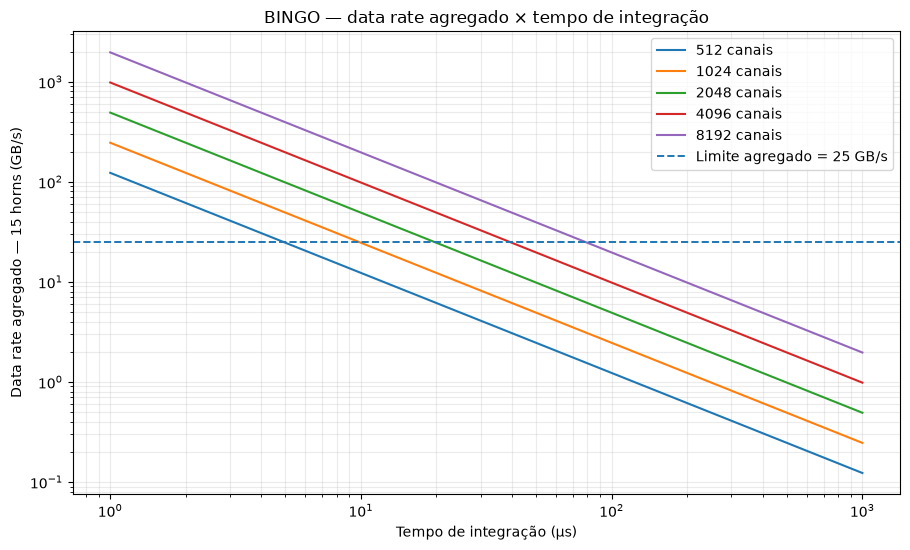

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Baseline agreed in the discussion:
# 8 scalar output components, 16 bit/component, 15 horns.
n_ffts = [512, 1024, 2048, 4096, 8192]
t_us = np.logspace(0, 3, 400)  # 1 us ... 1 ms
n_words = 8
bits_per_word = 16
n_horns = 15

fig, ax = plt.subplots(figsize=(9.2, 5.6))

for n_fft in n_ffts:
    bits_per_spectrum = n_fft * n_words * bits_per_word
    rate_total_GBs = (bits_per_spectrum / (t_us * 1e-6) / 8 * n_horns) / 1e9
    ax.plot(t_us, rate_total_GBs, label=f"{n_fft} canais")

ax.axhline(25, linestyle="--", linewidth=1.4, label="Limite agregado = 25 GB/s")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Tempo de integração (µs)")
ax.set_ylabel("Data rate agregado — 15 horns (GB/s)")
ax.set_title("BINGO — data rate agregado × tempo de integração")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()

plt.show()


| $N_{\rm FFT}$ | $t_{\rm FFT}$ | $t_{\rm int,min}$ | FFTs/int. | Spectrum | Rate/horn |   **15 horns** | Pacotes/espectro* | **Packet rate total*** |
| --------------: | --------------: | ------------------: | --------: | -------: | --------: | -------------: | ----------------: | ---------------------: |
|         **512** |        1.365 µs |        **5.461 µs** |         4 |    8 KiB | 1.50 GB/s | **22.50 GB/s** |                 1 |          **2.75 Mpps** |
|            1024 |        2.731 µs |           10.923 µs |         4 |   16 KiB | 1.50 GB/s | **22.50 GB/s** |                 2 |          **2.75 Mpps** |
|            2048 |        5.461 µs |           21.845 µs |         4 |   32 KiB | 1.50 GB/s | **22.50 GB/s** |                 4 |          **2.75 Mpps** |
|        **4096** |       10.923 µs |       **43.691 µs** |         4 |   64 KiB | 1.50 GB/s | **22.50 GB/s** |                 8 |          **2.75 Mpps** |
|            8192 |       21.845 µs |           87.381 µs |         4 |  128 KiB | 1.50 GB/s | **22.50 GB/s** |                16 |          **2.75 Mpps** |


|      FFT |   DSP + RFI |  BRAM + RFI |   LUT + RFI |
| -------: | ----------: | ----------: | ----------: |
|  **512** | **~19–27%** | **~14–24%** | **~20–31%** |
|     1024 |     ~21–30% |     ~19–30% |     ~24–35% |
|     2048 |     ~23–34% |     ~28–39% |     ~30–42% |
| **4096** | **~28–37%** | **~38–53%** | **~35–50%** |
|     8192 |     ~35–50% |     ~55–75% |     ~45–65% |


#### Data Center

| Item           | Especificação mínima   | **Baseline recomendado**                                   |
| -------------- | ---------------------- | ---------------------------------------------------------- |
| Chassis        | rack, airflow para GPU | **2U/4U enterprise**                                       |
| CPU            | ≥32 cores              | **EPYC 32–48 cores, 1P**                                   |
| RAM            | 512 GB ECC             | **512 GB DDR5 ECC, 12 canais preferencialmente populados** |
| GPU            | ≥40 GB ECC, ≥1.3 TB/s  | **A100 80 GB PCIe ou equivalente**                         |
| NIC            | ≥100GbE                | **ConnectX-6 Dx 100GbE ou superior**                       |
| NVMe           | ≥30 TB raw             | **4 × 7.68 TB enterprise U.2/U.3**                         |
| NVMe endurance | ≥1 DWPD                | **≥1 DWPD + PLP**                                          |
| PSU            | redundante             | **2 × ~1.6–2 kW**                                          |
| Management     | BMC/IPMI/Redfish       | obrigatório                                                |
| Warranty       | ≥3 anos                | **5 anos desejável**                                       |


| Subsistema                        |  Qtd. | **Budget unitário** |   **Subtotal** |
| --------------------------------- | ----: | ------------------: | -------------: |
| Compute server base, sem GPU/NVMe |     4 |           R$90–130k | **R$360–520k** |
| GPU HPC ≥40 GB ECC / ≥1.3 TB/s    |     4 |            R$50–90k | **R$200–360k** |
| Enterprise NVMe 7.68 TB           | 16–32 |            R$8–15k* | **R$128–480k** |
| Warm-storage chassis/controller   |     1 |          R$100–180k | **R$100–180k** |
| 30 TB enterprise HDD              |    16 |              ~R$14k |    **~R$224k** |
| Rack/PDUs/cabling                 |  lote |                   — |  **R$50–100k** |


| GPU                           |     VRAM / tipo | BW da memória |       PCIe |  Potência | ECC / operação contínua  | Adequação à dedispersão 10–100 µs                                                                                 |
| ----------------------------- | --------------: | ------------: | ---------: | --------: | ------------------------ | ----------------------------------------------------------------------------------------------------------------- |
| RTX 4090                      |    24 GB GDDR6X |     1,01 TB/s |    4.0 ×16 |     450 W | limitada; placa consumer | Boa para desenvolvimento e um fluxo moderado; VRAM e robustez limitam produção                                    |
| RTX 5090                      |     32 GB GDDR7 |     1,79 TB/s |    5.0 ×16 |     575 W | limitada; placa consumer | Excelente desempenho bruto/custo; consumo alto e menor previsibilidade operacional                                |
| L40S                          | 48 GB GDDR6 ECC |      864 GB/s |    4.0 ×16 |     350 W | sim; passiva, datacenter | Robusta, mas largura de banda relativamente baixa para dedispersão; não é a escolha mais eficiente                |
| A100 PCIe 80 GB               |     80 GB HBM2e |     1,94 TB/s |    4.0 ×16 |     300 W | ECC, MIG, datacenter     | Muito adequada; memória grande e rápida, consumo razoável e ecossistema científico maduro                         |
| H100 PCIe 80 GB               |     80 GB HBM2e |     ≈2,0 TB/s |    5.0 ×16 |     350 W | ECC, MIG, datacenter     | Excelente, mas o ganho sobre a A100 PCIe pode ser pequeno em kernel puramente memory-bound                        |
| H100 SXM 80 GB                |      80 GB HBM3 |     3,35 TB/s | SXM/NVLink | até 700 W | datacenter               | Excelente desempenho, mas exige servidor específico e tem custo muito alto                                        |
| H200 SXM                      |    141 GB HBM3e |      4,8 TB/s | SXM/NVLink | até 700 W | datacenter               | Máximo desempenho e buffer; provavelmente excessiva para um nó BINGO                                              |
| RTX PRO 6000 Blackwell Server | 96 GB GDDR7 ECC |     1,60 TB/s |    5.0 ×16 | até 600 W | ECC, passiva, datacenter | Grande capacidade e implantação profissional; interessante para pipeline mista, mas não supera HBM em dedispersão |


### Sumário de custos

In [10]:
# ---------------------------------------------------------------------------
# Sumário de custos — consolidação dos valores levantados no notebook
# ---------------------------------------------------------------------------
COTACAO_SUM = dolar_cheio  # R$ por US$ (célula "Custo Cabeamento RF")

# --- blocos comuns ----------------------------------------------------------
BLOCOS_BASE = [
    {
        "Bloco": "Torre — Requisitos Mínimos",
        "O que inclui": (
            "cabos RF, gabinetes, alimentação/DPS, UPS 6 kVA, clock/1PPS, "
            "QSFP+ 40G, tronco OS2, DIOs, rede 1 GbE, monitoramento, SPDA e "
            "comissionamento — é o mesmo valor rotulado 'Custo Cabeamento RF' "
            "(US$ 72–132 mil)"
        ),
        "Mínimo (R$)": 72_000 * COTACAO_SUM,
        "Máximo (R$)": 132_000 * COTACAO_SUM,
    },
    {
        "Bloco": "Casa de Comando",
        "O que inclui": (
            "switch 40/100GbE, NIC 2×100GbE, ópticos/DACs do uplink e "
            "rack/PDUs/organização óptica"
        ),
        "Mínimo (R$)": 14_500 * COTACAO_SUM,
        "Máximo (R$)": 32_000 * COTACAO_SUM,
    },
    {
        "Bloco": "Itens necessários",
        "O que inclui": (
            "estação meteorológica, master clock, sensores de geometria, "
            "as built + posicionamento, baterias, placas solares, "
            "ar-condicionado, projetos, receptores e operacional"
        ),
        "Mínimo (R$)": float(necessarios),
        "Máximo (R$)": float(necessarios),
    },
]

# --- Data Center: as duas alternativas levantadas no notebook ---------------
DC_A = {
    "Bloco": "Data Center (A) — 3 nós + storage DIY",
    "O que inclui": (
        "tabelas 'Nós de computação' (US$ 66,45–104,7 mil) e 'Storage DIY' "
        "(US$ 10,3–16,5 mil)"
    ),
    "Mínimo (R$)": (66_450 + 10_300) * COTACAO_SUM,
    "Máximo (R$)": (104_700 + 16_500) * COTACAO_SUM,
}

DC_B_ITENS = [
    ("Compute server base, sem GPU/NVMe", 4, 360_000, 520_000),
    ("GPU HPC ≥40 GB ECC / ≥1,3 TB/s", 4, 200_000, 360_000),
    ("Enterprise NVMe 7,68 TB", "16–32", 128_000, 480_000),
    ("Warm-storage chassis/controller", 1, 100_000, 180_000),
    ("HDD enterprise 30 TB", 16, 224_000, 224_000),
    ("Rack/PDUs/cabling", "lote", 50_000, 100_000),
]
DC_B = {
    "Bloco": "Data Center (B) — baseline FRB",
    "O que inclui": (
        "tabela de budget da seção FRB: 4 servidores, GPUs HPC, NVMe, "
        "storage warm, HDDs de 30 TB e rack/PDUs"
    ),
    "Mínimo (R$)": float(sum(item[2] for item in DC_B_ITENS)),
    "Máximo (R$)": float(sum(item[3] for item in DC_B_ITENS)),
}


def fechar(linha):
    """Completa a linha do resumo com o custo médio."""
    minimo, maximo = linha["Mínimo (R$)"], linha["Máximo (R$)"]
    return {
        "Bloco": linha["Bloco"],
        "O que inclui": linha["O que inclui"],
        "Mínimo (R$)": minimo,
        "Máximo (R$)": maximo,
        "Médio (R$)": (minimo + maximo) / 2,
    }


def somar(linhas):
    """Soma mínimo, máximo e médio de um conjunto de linhas."""
    minimo = sum(linha["Mínimo (R$)"] for linha in linhas)
    maximo = sum(linha["Máximo (R$)"] for linha in linhas)
    return minimo, maximo, (minimo + maximo) / 2


min_a, max_a, med_a = somar([*BLOCOS_BASE, DC_A])
min_b, max_b, med_b = somar([*BLOCOS_BASE, DC_B])

resumo = pd.DataFrame(
    [
        *[fechar(linha) for linha in BLOCOS_BASE],
        fechar(DC_A),
        fechar(DC_B),
        {
            "Bloco": "TOTAL — com Data Center (A)",
            "O que inclui": "Torre + Casa de Comando + Itens necessários + A",
            "Mínimo (R$)": min_a,
            "Máximo (R$)": max_a,
            "Médio (R$)": med_a,
        },
        {
            "Bloco": "TOTAL — com Data Center (B)",
            "O que inclui": "Torre + Casa de Comando + Itens necessários + B",
            "Mínimo (R$)": min_b,
            "Máximo (R$)": max_b,
            "Médio (R$)": med_b,
        },
    ]
)

detalhe_b = pd.DataFrame(
    [
        {
            "Subsistema": nome,
            "Qtd.": qtd,
            "Mínimo (R$)": minimo,
            "Máximo (R$)": maximo,
            "Médio (R$)": (minimo + maximo) / 2,
        }
        for nome, qtd, minimo, maximo in DC_B_ITENS
    ]
)

recursos_total = float(df_RECURSOS["Amount"].sum())
balanco = pd.DataFrame(
    [
        {"Item": "Recursos disponíveis (FAPESQ + FINEP)", "Valor (R$)": recursos_total},
        {"Item": "Custo total — opção A (médio)", "Valor (R$)": med_a},
        {"Item": "Custo total — opção B (médio)", "Valor (R$)": med_b},
        {"Item": "Saldo — opção A", "Valor (R$)": recursos_total - med_a},
        {"Item": "Saldo — opção B", "Valor (R$)": recursos_total - med_b},
    ]
)

FORMATOS_RS = {"Mínimo (R$)": reais, "Máximo (R$)": reais, "Médio (R$)": reais}
uso_a = f"{med_a / recursos_total:.1%}".replace(".", ",")
uso_b = f"{med_b / recursos_total:.1%}".replace(".", ",")

display(
    Markdown(
        "**Resumo por bloco**\n\n"
        + markdown_tabela(resumo, FORMATOS_RS)
        + "\n\n**Detalhe do Data Center (B) — baseline FRB**\n\n"
        + markdown_tabela(detalhe_b, FORMATOS_RS)
        + "\n\n**Recursos × custo**\n\n"
        + markdown_tabela(balanco, {"Valor (R$)": reais})
        + "\n\n*Cotação US$ 1 = R$ 8,00; médio = (mín + máx)/2. O valor rotulado "
        "'Custo Cabeamento RF' (US$ 72–132 mil) é o subtotal da Torre e não é "
        f"somado em duplicidade. Uso dos recursos: {uso_a} (opção A) e {uso_b} "
        "(opção B).*"
    )
)

**Resumo por bloco**

| Bloco | O que inclui | Mínimo (R$) | Máximo (R$) | Médio (R$) |
| --- | --- | ---: | ---: | ---: |
| Torre — Requisitos Mínimos | cabos RF, gabinetes, alimentação/DPS, UPS 6 kVA, clock/1PPS, QSFP+ 40G, tronco OS2, DIOs, rede 1 GbE, monitoramento, SPDA e comissionamento — é o mesmo valor rotulado 'Custo Cabeamento RF' (US$ 72–132 mil) | R$ 576.000,00 | R$ 1.056.000,00 | R$ 816.000,00 |
| Casa de Comando | switch 40/100GbE, NIC 2×100GbE, ópticos/DACs do uplink e rack/PDUs/organização óptica | R$ 116.000,00 | R$ 256.000,00 | R$ 186.000,00 |
| Itens necessários | estação meteorológica, master clock, sensores de geometria, as built + posicionamento, baterias, placas solares, ar-condicionado, projetos, receptores e operacional | R$ 4.985.000,00 | R$ 4.985.000,00 | R$ 4.985.000,00 |
| Data Center (A) — 3 nós + storage DIY | tabelas 'Nós de computação' (US$ 66,45–104,7 mil) e 'Storage DIY' (US$ 10,3–16,5 mil) | R$ 614.000,00 | R$ 969.600,00 | R$ 791.800,00 |
| Data Center (B) — baseline FRB | tabela de budget da seção FRB: 4 servidores, GPUs HPC, NVMe, storage warm, HDDs de 30 TB e rack/PDUs | R$ 1.062.000,00 | R$ 1.864.000,00 | R$ 1.463.000,00 |
| TOTAL — com Data Center (A) | Torre + Casa de Comando + Itens necessários + A | R$ 6.291.000,00 | R$ 7.266.600,00 | R$ 6.778.800,00 |
| TOTAL — com Data Center (B) | Torre + Casa de Comando + Itens necessários + B | R$ 6.739.000,00 | R$ 8.161.000,00 | R$ 7.450.000,00 |

**Detalhe do Data Center (B) — baseline FRB**

| Subsistema | Qtd. | Mínimo (R$) | Máximo (R$) | Médio (R$) |
| --- | --- | ---: | ---: | ---: |
| Compute server base, sem GPU/NVMe | 4 | R$ 360.000,00 | R$ 520.000,00 | R$ 440.000,00 |
| GPU HPC ≥40 GB ECC / ≥1,3 TB/s | 4 | R$ 200.000,00 | R$ 360.000,00 | R$ 280.000,00 |
| Enterprise NVMe 7,68 TB | 16–32 | R$ 128.000,00 | R$ 480.000,00 | R$ 304.000,00 |
| Warm-storage chassis/controller | 1 | R$ 100.000,00 | R$ 180.000,00 | R$ 140.000,00 |
| HDD enterprise 30 TB | 16 | R$ 224.000,00 | R$ 224.000,00 | R$ 224.000,00 |
| Rack/PDUs/cabling | lote | R$ 50.000,00 | R$ 100.000,00 | R$ 75.000,00 |

**Recursos × custo**

| Item | Valor (R$) |
| --- | ---: |
| Recursos disponíveis (FAPESQ + FINEP) | R$ 17.248.277,73 |
| Custo total — opção A (médio) | R$ 6.778.800,00 |
| Custo total — opção B (médio) | R$ 7.450.000,00 |
| Saldo — opção A | R$ 10.469.477,73 |
| Saldo — opção B | R$ 9.798.277,73 |

*Cotação US$ 1 = R$ 8,00; médio = (mín + máx)/2. O valor rotulado 'Custo Cabeamento RF' (US$ 72–132 mil) é o subtotal da Torre e não é somado em duplicidade. Uso dos recursos: 39,3% (opção A) e 43,2% (opção B).*